In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import soundfile as sf
import librosa


COLOR = "#FFFFFF"
IMG_OUTPUT_PATH = Path("img")
SAVE_PARAMS = {"dpi": 300, "bbox_inches": "tight", "transparent": True}

XTICKS = np.array([31.25, 62.5, 125, 250, 500, 1000, 2000, 4000, 8000])
XTICK_LABELS = np.array(["31.25", "62.5", "125", "250", "500", "1k", "2k", "4k", "8k"])

plt.rcParams.update({"font.size": 20})


def save_spectrum(output_path):
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, **SAVE_PARAMS)

def plot_spectrum_db_in_octaves_and_save(
    frequencies, magnitude_spectrum, output_path: Path
):
    plt.figure(figsize=(12, 6))
    plt.semilogx(frequencies, magnitude_spectrum, COLOR)
    plt.ylim([-60, 0])
    plt.xticks(XTICKS, XTICK_LABELS)
    min_x = 29
    plt.xlim([min_x, frequencies[-1]])
    plt.grid()
    plt.xlabel("frequency [Hz]")
    plt.ylabel("magnitude [dBFS]")
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # plt.show() # closes the figure
    save_spectrum(output_path)
    plt.close()


def main():
    signal, sample_rate = sf.read(
        Path(".") / "TestAudio2.mp3"
    )
    # Convert stereo to mono if necessary
    if signal.ndim > 1:
        signal = signal[:, 0]  # Take the first channel

    print(f"Signal's sample rate: {sample_rate} Hz.")
#    magnitude_spectrum = np.abs(np.fft.rfft(signal))
#    frequencies = np.fft.rfftfreq(signal.shape[0], 1 / sample_rate)

#    normalized_magnitude_spectrum = magnitude_spectrum / np.amax(magnitude_spectrum)
#    magnitude_spectrum_db = 20 * np.log10(normalized_magnitude_spectrum)
    return signal, sample_rate
signal, sample_rate = main()

if __name__ == "__main__":
    main()

n_segments = 10
num_samples = signal.shape[0]
num_samples_per_segment = num_samples // n_segments
print(f"Number of samples per segment: {num_samples_per_segment}")

Signal's sample rate: 44100 Hz.
Signal's sample rate: 44100 Hz.
Number of samples per segment: 996484


In [2]:


spectra_list = []
n_segments = 2000
num_samples = signal.shape[0]
num_samples_per_segment = num_samples // n_segments

for i in range(n_segments):
    start_sample = i * num_samples_per_segment
    end_sample = start_sample + num_samples_per_segment
    segment = signal[start_sample:end_sample]

    # Compute FFT
    magnitude_spectrum = np.abs(np.fft.rfft(segment))
    # Store frequency axis once
    if i == 0:
        freq_axis = np.fft.rfftfreq(segment.shape[0], 1 / sample_rate)

    # Normalize and convert to dB
    max_val = np.amax(magnitude_spectrum)
    if max_val > 0:
        normalized_spectrum = magnitude_spectrum / max_val
    else:
        normalized_spectrum = magnitude_spectrum

    magnitude_spectrum_db = 20 * np.log10(normalized_spectrum + 1e-10) # Added epsilon to avoid log(0)
    spectra_list.append(magnitude_spectrum_db)

# Stack into 2D array (Time x Frequency)
spectrogram_data = np.vstack(spectra_list)

print(f"Spectrogram data shape: {spectrogram_data.shape}")
print(f"Frequency axis shape: {freq_axis.shape}")

Spectrogram data shape: (2000, 2492)
Frequency axis shape: (2492,)


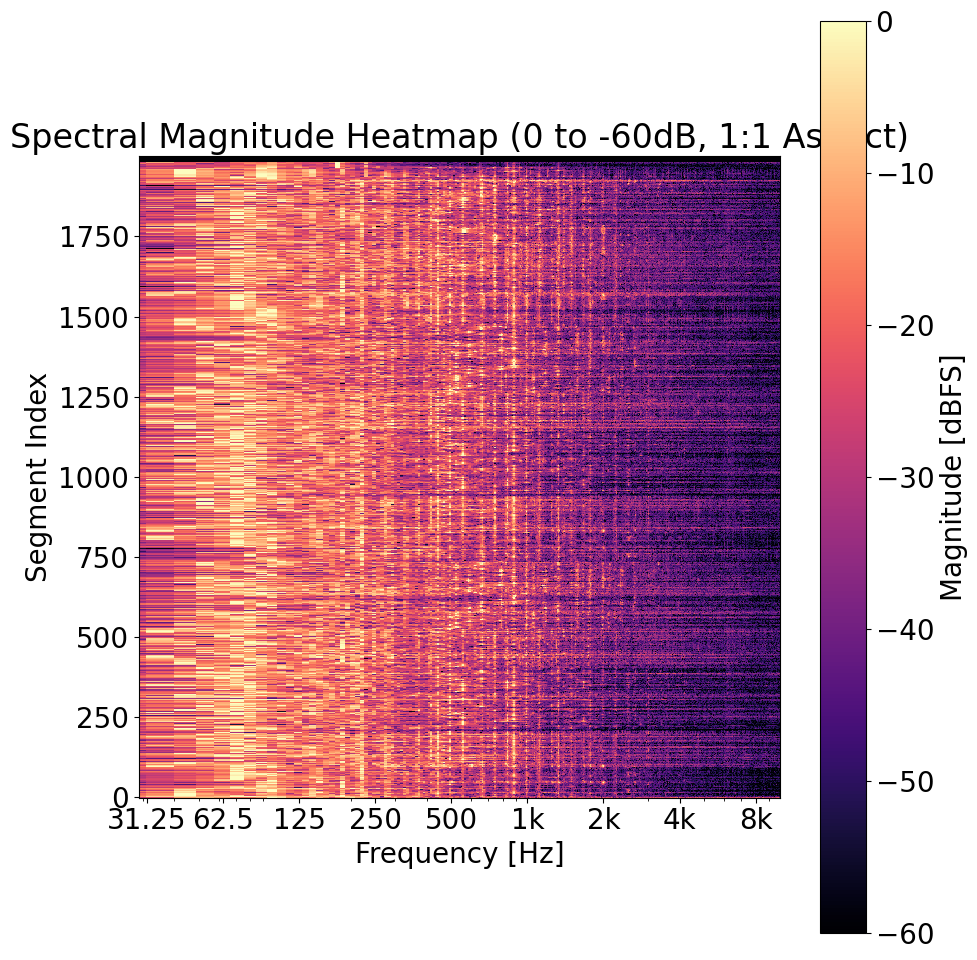

In [3]:
# Prepare data and clip values below -60dB
clipped_spectrogram = np.clip(spectrogram_data, -60, 0)

plt.figure(figsize=(10, 10))
ax = plt.gca()

# Use pcolormesh with fixed vmin and vmax for the dB range
pc = ax.pcolormesh(freq_axis, np.arange(n_segments), clipped_spectrogram, cmap='magma', shading='auto', vmin=-60, vmax=0)

# Set X-axis to log scale and formatting
ax.set_xscale('log')
ax.set_xticks(XTICKS)
ax.set_xticklabels(XTICK_LABELS)
ax.set_xlim([29, 10000])

# Labels and Title
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Segment Index')
ax.set_title('Spectral Magnitude Heatmap (0 to -60dB, 1:1 Aspect)')

# Colorbar with fixed range
cbar = plt.colorbar(pc)
cbar.set_label('Magnitude [dBFS]')

# Force Square Aspect Ratio (1:1)
ax.set_box_aspect(1)

plt.tight_layout()
plt.show()

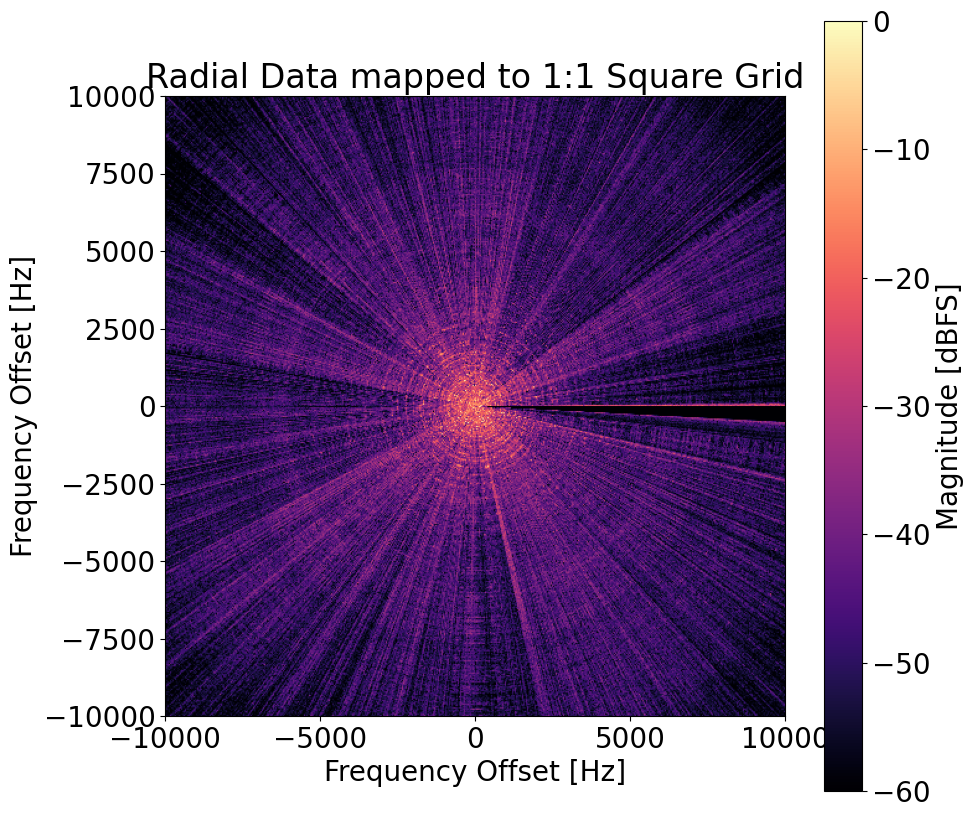

In [4]:
from scipy.interpolate import RegularGridInterpolator

# Define the bounds based on max radius (Frequency)
max_freq = 10000
res = 500  # Resolution of the output square grid

# Create the Cartesian grid (x, y) from -max_freq to max_freq
x = np.linspace(-max_freq, max_freq, res)
y = np.linspace(-max_freq, max_freq, res)
X, Y = np.meshgrid(x, y)

# Convert Cartesian grid to Polar coordinates for lookup
# R is the radius (Frequency), Phi is the angle (Time/Segment)
R = np.sqrt(X**2 + Y**2)
Phi = np.arctan2(Y, X)
# Adjust Phi from [-pi, pi] to [0, 2*pi] to match our angle definition
Phi = np.mod(Phi, 2 * np.pi)

# Prepare the interpolator using the existing spectrogram data
# spectrogram_data shape is (n_segments, n_freqs)
# Angle axis (Time): 0 to 2pi
# Radius axis (Freq): freq_axis
clipped_spectrogram = np.clip(spectrogram_data, -60, 0)

# Note: RegularGridInterpolator expects strictly increasing coordinates
# Ensure freq_axis is unique and sorted
interp = RegularGridInterpolator(
    (np.linspace(0, 2 * np.pi, n_segments), freq_axis),
    clipped_spectrogram,
    method='linear',
    bounds_error=False,
    fill_value=-60
)

# Interpolate the data onto the square grid
# We stack Phi and R to create points for interpolation
points = np.stack([Phi.ravel(), R.ravel()], axis=-1)
Z = interp(points).reshape(res, res)

# Plotting
plt.figure(figsize=(10, 10))
plt.imshow(Z, extent=[-max_freq, max_freq, -max_freq, max_freq],
           origin='lower', cmap='magma', vmin=-60, vmax=0)

plt.colorbar(label='Magnitude [dBFS]')
plt.title('Radial Data mapped to 1:1 Square Grid')
plt.xlabel('Frequency Offset [Hz]')
plt.ylabel('Frequency Offset [Hz]')
plt.grid(False)
plt.show()

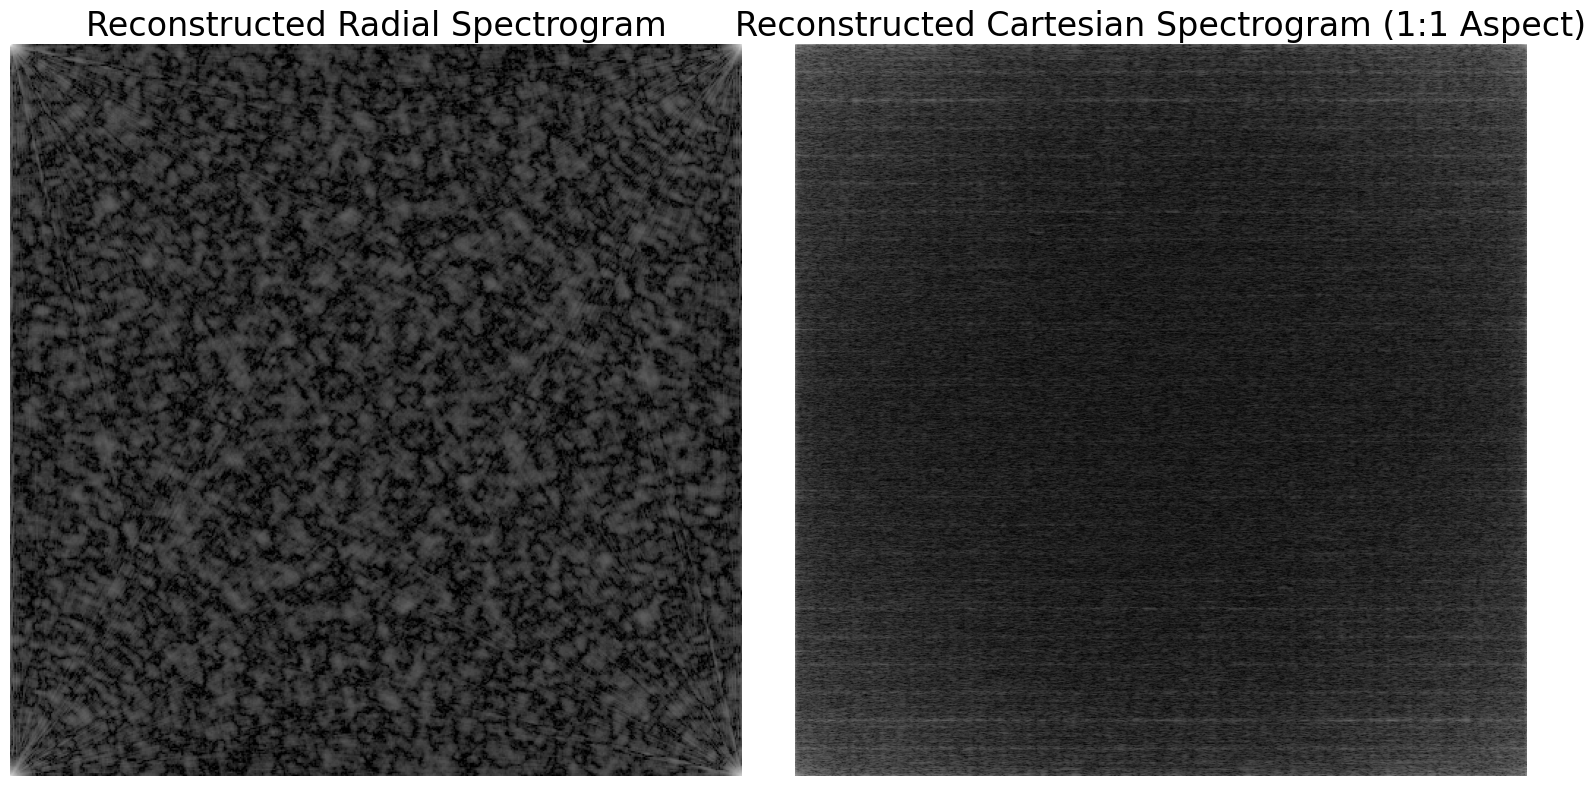

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Reconstruct Cartesian Radial Heatmap
linear_Z = 10**(Z / 20)
ft_inv_shifted = np.fft.ifftshift(linear_Z)
recon_cartesian = np.abs(np.fft.ifft2(ft_inv_shifted))
# Apply log scaling for visibility
recon_cart_viz = 20 * np.log10(recon_cartesian + 1e-10)

# 2. Reconstruct original Spectral Heatmap (Segments x Freq)
linear_spec = 10**(spectrogram_data / 20)
# Inverse FFT along frequency axis
recon_spec_raw = np.abs(np.fft.ifft2(np.fft.ifftshift(linear_spec)))
#recon_spec_raw = np.abs(np.fft.ifft2(linear_spec))
# Apply log scaling for sensitivity/visibility
recons_spec_viz = 20 * np.log10(recon_spec_raw + 1e-10)

# Plotting
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
# Scale based on percentiles to ignore outliers and show data structure
plt.imshow(recon_cart_viz, cmap='gray', vmin=np.percentile(recon_cart_viz, 5))
plt.title('Reconstructed Radial Spectrogram')
plt.axis('off')

plt.subplot(1, 2, 2)
# Using aspect='auto' allows the image to stretch to fill the 1:1 box aspect
plt.imshow(recons_spec_viz, cmap='gray', vmin=np.percentile(recons_spec_viz, 5), aspect='auto')
plt.title('Reconstructed Cartesian Spectrogram (1:1 Aspect)')
plt.axis('off')
ax = plt.gca()
ax.set_box_aspect(1)

plt.tight_layout()
plt.show()